# Ejemplo de transformación cíclica y ventanas de tiempo

**Autor:** Jazna Meza Hidalgo

**Correo Electrónico:** ja.meza@profesor.duoc.cl

**Fecha de Creación:** Abril de 2026  
**Versión:** 1.0  

---

## Descripción

Este notebook ofrece la explicación del trabajo con la transformación cíclica y las ventanas de tiempo, muy útiles cuando se trabaja con temas de tiempo.

Mantiene el uso de pipeline como buena práctica de la industria.


---

## Requisitos de Software

Este notebook fue desarrollado con Python 3.12. A continuación se listan las bibliotecas necesarias:

- pandas (>=1.1.0)
- matplotlib (3.7.1)
- numpy (2.0.2)


Para verificar la versión instalada ejecutar usando el siguiente comando, usando la librería de la cual quieres saber la versión:

```python
import pandas as pd
print(pd.__version__)
````

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer

from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split


In [2]:
!wget https://raw.githubusercontent.com/JaznaLaProfe/datos/master/data_clima/dataset_clima_sur_chile.csv

--2026-05-14 19:03:16--  https://raw.githubusercontent.com/JaznaLaProfe/datos/master/data_clima/dataset_clima_sur_chile.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1970332 (1.9M) [text/plain]
Saving to: ‘dataset_clima_sur_chile.csv’

dataset_clima_sur_c 100%[===================>]   1.88M  --.-KB/s    in 0.07s   

2026-05-14 19:03:16 (27.9 MB/s) - ‘dataset_clima_sur_chile.csv’ saved [1970332/1970332]



In [3]:
class Winsorizer(BaseEstimator, TransformerMixin):
  """
  Tratamiento de atípicos

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  columns_ : array-like
    Nombres de las columnas a transformar.
  limits : tuple
    % de los extremos a descartar
  """
  def __init__(self, limits=(0.05, 0.05)):
    self.limits = limits

  def fit(self, X, y=None):
    # Guardar nombres si es DataFrame, si no generar nombres genéricos
    if isinstance(X, pd.DataFrame):
      self.columns_ = X.columns
    else:
      self.columns_ = np.arange(X.shape[1])
    return self

  def transform(self, X):
    X = pd.DataFrame(X, columns=self.columns_)
    for col in self.columns_:
      lower = X[col].quantile(self.limits[0])
      upper = X[col].quantile(1 - self.limits[1])
      X[col] = np.clip(X[col], lower, upper)
    return X.values

  def get_feature_names_out(self, input_features=None):
    if input_features is None:
      return np.array(self.columns_)
    else:
      return np.array(input_features)

In [4]:
class CorrelationFilter(BaseEstimator, TransformerMixin):
  """
  Eliminación de variables correlacionadas

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  columns_to_drop_ : array-like
    Nombres de las columnas a eliminar.
  threshold : float
    Umbral de correlación.
  Returns
  -------
  DataFrame
    Conjunto de datos sin variables correlacionadas.
  """
  def __init__(self, threshold=0.9):
    self.threshold = threshold
    self.columns_to_drop_ = None

  def fit(self, X, y=None):
    X_df = pd.DataFrame(X)

    corr_matrix = X_df.corr().abs()
    upper = corr_matrix.where(
      np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    self.columns_to_drop_ = [
        col for col in upper.columns if any(upper[col] > self.threshold)
    ]

    return self

  def transform(self, X):
    X_df = pd.DataFrame(X)
    X_filtered = X_df.drop(columns=self.columns_to_drop_, errors="ignore")
    return X_filtered.values

In [5]:
def tratar_duplicados(X : pd.DataFrame, drop = True):
  """
  Tratamiento de duplicados

  Parámetros
  ----------
  X : DataFrame
    Conjunto de datos.
  drop : bool
    Si se deben eliminar los duplicados.

  Retorna
  -------
  DataFrame
    Conjunto de datos sin duplicados.
  """
  return X.drop_duplicates() if drop else X

In [6]:
data = pd.read_csv("dataset_clima_sur_chile.csv")
data.head()

,fecha,ciudad,temperatura,humedad,lluvia
0,2023-01-01 00:00:00,Concepcion,22.993428,72.617357,0.000000
1,2023-01-01 01:00:00,Concepcion,21.070335,77.189022,13.949143
2,2023-01-01 02:00:00,Concepcion,26.034869,68.191219,3.229363
3,2023-01-01 03:00:00,Concepcion,20.310436,83.503697,0.000000
4,2023-01-01 04:00:00,Concepcion,24.304465,77.142473,0.000000


In [7]:
data.shape

(26280, 5)

In [8]:
data.ciudad.unique()

array(['Concepcion', 'Temuco', 'Valdivia'], dtype=object)

In [9]:
data["fecha"] = pd.to_datetime(data["fecha"])
data["hora"] = data["fecha"].dt.hour
data["mes"] = data["fecha"].dt.month

data["hora_sin"] = np.sin(2 * np.pi * data["hora"] / 24)
data["hora_cos"] = np.cos(2 * np.pi * data["hora"] / 24)

data["mes_sin"] = np.sin(2 * np.pi * data["mes"] / 12)
data["mes_cos"] = np.cos(2 * np.pi * data["mes"] / 12)

In [10]:
data = data.sort_values(["ciudad", "fecha"])

data["temp_rolling_6h"] = data.groupby("ciudad")["temperatura"].rolling(6).mean().reset_index(0, drop=True)

data["lluvia_rolling_24h"] = data.groupby("ciudad")["lluvia"].rolling(24).sum().reset_index(0, drop=True)

rolling_cols = ["temp_rolling_6h", "lluvia_rolling_24h"]
data["nulo_esperado"] = data[rolling_cols].isna().any(axis=1)

In [11]:
data.head()

,fecha,ciudad,temperatura,humedad,lluvia,hora,mes,hora_sin,hora_cos,mes_sin,mes_cos,temp_rolling_6h,lluvia_rolling_24h,nulo_esperado
0,2023-01-01 00:00:00,Concepcion,22.993428,72.617357,0.000000,0,1,0.000000,1.000000,0.5,0.866025,NaN,NaN,True
1,2023-01-01 01:00:00,Concepcion,21.070335,77.189022,13.949143,1,1,0.258819,0.965926,0.5,0.866025,NaN,NaN,True
2,2023-01-01 02:00:00,Concepcion,26.034869,68.191219,3.229363,2,1,0.500000,0.866025,0.5,0.866025,NaN,NaN,True
3,2023-01-01 03:00:00,Concepcion,20.310436,83.503697,0.000000,3,1,0.707107,0.707107,0.5,0.866025,NaN,NaN,True
4,2023-01-01 04:00:00,Concepcion,24.304465,77.142473,0.000000,4,1,0.866025,0.500000,0.5,0.866025,NaN,NaN,True


In [12]:
otras_cols = data.columns.difference(rolling_cols)
data["nulo_no_esperado"] = data[otras_cols].isna().any(axis=1)

In [13]:
data["nulo_no_esperado"].sum()

np.int64(0)

In [14]:
data = data.dropna()

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26211 entries, 23 to 26279
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   fecha               26211 non-null  datetime64[ns]
 1   ciudad              26211 non-null  object        
 2   temperatura         26211 non-null  float64       
 3   humedad             26211 non-null  float64       
 4   lluvia              26211 non-null  float64       
 5   hora                26211 non-null  int32         
 6   mes                 26211 non-null  int32         
 7   hora_sin            26211 non-null  float64       
 8   hora_cos            26211 non-null  float64       
 9   mes_sin             26211 non-null  float64       
 10  mes_cos             26211 non-null  float64       
 11  temp_rolling_6h     26211 non-null  float64       
 12  lluvia_rolling_24h  26211 non-null  float64       
 13  nulo_esperado       26211 non-null  bool          

In [16]:
data.head()

,fecha,ciudad,temperatura,humedad,lluvia,hora,mes,hora_sin,hora_cos,mes_sin,mes_cos,temp_rolling_6h,lluvia_rolling_24h,nulo_esperado,nulo_no_esperado
23,2023-01-01 23:00:00,Concepcion,19.127388,81.437113,2.476895,23,1,-0.258819,0.965926,0.5,0.866025,18.371952,66.620488,False,False
24,2023-01-02 00:00:00,Concepcion,20.996486,79.014483,0.000000,0,1,0.000000,1.000000,0.5,0.866025,19.062036,66.620488,False,False
25,2023-01-02 01:00:00,Concepcion,25.610469,68.702398,0.000000,1,1,0.258819,0.965926,0.5,0.866025,20.203521,52.671345,False,False
26,2023-01-02 02:00:00,Concepcion,25.526535,87.718621,0.000000,2,1,0.500000,0.866025,0.5,0.866025,20.991416,49.441981,False,False
27,2023-01-02 03:00:00,Concepcion,25.886640,66.979469,0.000000,3,1,0.707107,0.707107,0.5,0.866025,22.701362,49.441981,False,False


In [17]:
selected_columns = ["ciudad", "hora_sin", "hora_cos", "mes_sin", "mes_cos", "temp_rolling_6h",
                    "lluvia_rolling_24h", "temperatura"]

data_for_model = data[selected_columns]
target = "temperatura"

X = data_for_model.drop(columns=[target])
y = data[target]

features_num = ["hora_sin", "hora_cos", "mes_sin", "mes_cos", "temp_rolling_6h", "lluvia_rolling_24h"]
features_cat = ["ciudad"]
# Preprocesamiento numérico: imputación + transformación
numeric_transformer = Pipeline(steps=[
    ("winsorizer", Winsorizer()),
    ("imputer", SimpleImputer(strategy="mean")),
    ("escalado", StandardScaler())
])

# Preprocesamiento categórico: imputación + one-hot encoding
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

# Combina en un ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, make_column_selector(dtype_include=np.number)),
        ("cat", categorical_transformer, features_cat)
    ],
    remainder="drop"
)

# Crea el pipeline
pipeline_lr_temperature = Pipeline(steps=[
    ("duplicados", FunctionTransformer(tratar_duplicados,
                                       kw_args={"drop": False})),
    ("preprocesamiento", preprocessor),
    ("colinealidad", CorrelationFilter(threshold=0.9)),
    ("modelo", LinearRegression())
])

In [18]:
# Calcula la matriz de correlaciones
correlaciones = data_for_model.corr(numeric_only=True)

# Ver correlación con la variable objetivo
correlacion_objetivo = correlaciones[target].sort_values(ascending=False)

correlacion_objetivo

,temperatura
temperatura,1.000000
temp_rolling_6h,0.875251
hora_sin,0.599408
mes_cos,0.568403
mes_sin,0.320959
hora_cos,0.000008
lluvia_rolling_24h,-0.521725


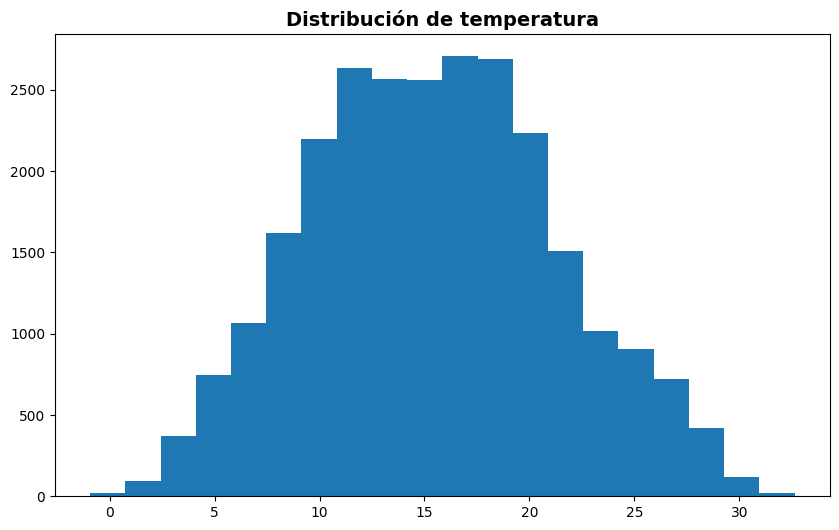

In [19]:
data[target].hist(bins=20, figsize=(10,6), grid=False)
plt.title("Distribución de temperatura", fontsize=14, fontweight="bold")
plt.show()

In [20]:
# División train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=29)

# Entrenamiento
pipeline_lr_temperature.fit(X_train, y_train)

Pipeline(steps=[('duplicados',
                 FunctionTransformer(func=<function tratar_duplicados at 0x798f0d365da0>,
                                     kw_args={'drop': False})),
                ('preprocesamiento',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('winsorizer',
                                                                   Winsorizer()),
                                                                  ('imputer',
                                                                   SimpleImputer()),
                                                                  ('escalado',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x798ee0a40ce0>),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['ciudad'])])),
                ('colinealidad', CorrelationFilter()),
                ('modelo', LinearRegression())])

In [21]:
# Predicciones
y_pred = pipeline_lr_temperature.predict(X_test)

# Evaluación
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Métricas del modelo ---")
print(f"{'R²' :<15}: {r2:.3f}")
print(f"{'MAE':<15}: {mae:,.2f}")


--- Métricas del modelo ---
R²             : 0.899
MAE            : 1.49


In [22]:
# Variables que fueron eliminadas por presentar colinealidad
pipeline_lr_temperature.named_steps["colinealidad"].columns_to_drop_

[]

In [23]:
print(f"{'R² en entrenamiento' :<25}: {pipeline_lr_temperature.score(X_train, y_train):.3f}")
print(f"{'R² en test' :<25}: {pipeline_lr_temperature.score(X_test, y_test):.3f}")

R² en entrenamiento      : 0.899
R² en test               : 0.899


In [24]:
X_train.columns

Index(['ciudad', 'hora_sin', 'hora_cos', 'mes_sin', 'mes_cos',
       'temp_rolling_6h', 'lluvia_rolling_24h'],
      dtype='object')

In [25]:
def transformacionCiclica(hora: int, mes:int) -> tuple[float, float]:
  hora_sin = np.sin(2 * np.pi * hora / 24)
  hora_cos = np.cos(2 * np.pi * hora / 24)
  mes_sin = np.sin(2 * np.pi * mes / 12)
  mes_cos = np.cos(2 * np.pi * mes / 12)
  return hora_sin, hora_cos, mes_sin, mes_cos


In [26]:
def recuperar_hora(hora_sin, hora_cos):
    angulo = np.arctan2(hora_sin, hora_cos)

    # convertir de [-pi, pi] a [0, 2pi]
    angulo = np.where(angulo < 0, angulo + 2*np.pi, angulo)

    # escalar a horas
    hora = angulo * 24 / (2 * np.pi)

    return np.round(hora).astype(int)

In [27]:
def recuperar_mes(mes_sin, mes_cos):
    angulo = np.arctan2(hora_sin, hora_cos)

    # convertir de [-pi, pi] a [0, 2pi]
    angulo = np.where(angulo < 0, angulo + 2*np.pi, angulo)

    # escalar a meses
    mes = angulo * 12 / (2 * np.pi)

    return np.round(mes).astype(int)

In [28]:
# Obtiene el promedio de la variable indicada en la ciudad indicada en el mes indicado
def get_mean(data: pd.DataFrame, ciudad: str, mes: int, indicator : str) -> float:
  """
  Obtiene el promedio de la variable indicada en la ciudad indicada en el mes indicado

  Parámetros
  ----------
  data : pd.DataFrame
    Conjunto de datos.
  ciudad : str
    Ciudad.
  mes : int
    Mes.
  indicator : str
    Variable a obtener el promedio.

  Retorna
  -------
  float
    Promedio.
  """
  data_preparada = data.copy()
  data_preparada["fecha"] = pd.to_datetime(data_preparada["fecha"])
  data_preparada["mes"] = data_preparada["fecha"].dt.month
  if ciudad in data_preparada["ciudad"].unique():
    return data_preparada.loc[(data_preparada["ciudad"] == ciudad) &
     (data_preparada["mes"] == mes), indicator].mean()
  else:
    raise ValueError(f"Ciudad {ciudad} no encontrada")

In [29]:
data_for_model.columns

Index(['ciudad', 'hora_sin', 'hora_cos', 'mes_sin', 'mes_cos',
       'temp_rolling_6h', 'lluvia_rolling_24h', 'temperatura'],
      dtype='object')

In [30]:
data.columns

Index(['fecha', 'ciudad', 'temperatura', 'humedad', 'lluvia', 'hora', 'mes',
       'hora_sin', 'hora_cos', 'mes_sin', 'mes_cos', 'temp_rolling_6h',
       'lluvia_rolling_24h', 'nulo_esperado', 'nulo_no_esperado'],
      dtype='object')

In [31]:
# Obtiene el promedio por mes y ciudad de temp_rolling_6h y lo convierte en una estructura para poder buscar después
data_temp = data.groupby(["ciudad", "mes"])["temp_rolling_6h"].mean()
data_temp = data_temp.reset_index()
data_temp = data_temp.pivot(index="ciudad", columns="mes", values="temp_rolling_6h")
data_temp

mes,1,2,3,4,5,6,7,8,9,10,11,12
ciudad,,,,,,,,,,,,
Concepcion,21.985836,21.981212,15.037260,15.029447,14.955583,10.023517,10.032588,9.914142,14.915669,15.078287,15.047425,22.031467
Temuco,22.026422,21.890881,14.961055,15.121970,15.043666,9.930710,9.909275,10.074473,14.935366,15.055181,14.993586,22.094617
Valdivia,22.048604,21.911843,15.002692,14.953825,15.042714,9.836141,10.033727,9.983157,15.000520,15.089295,14.857673,22.050060


In [32]:
data_lluvia = data.groupby(["ciudad", "mes"])["lluvia_rolling_24h"].mean()
data_lluvia = data_lluvia.reset_index()
data_lluvia = data_lluvia.pivot(index="ciudad", columns="mes", values="lluvia_rolling_24h")
data_lluvia

mes,1,2,3,4,5,6,7,8,9,10,11,12
ciudad,,,,,,,,,,,,
Concepcion,28.788827,30.377613,57.125086,55.983759,59.216158,89.631450,84.488789,97.407835,59.669001,57.574503,60.666932,30.296186
Temuco,31.615946,24.875467,57.890488,49.080296,55.880527,85.123806,80.342097,86.414718,61.296635,50.228760,65.344967,28.860701
Valdivia,26.978990,28.350356,57.560009,61.485519,51.493981,89.245468,83.079616,85.595070,57.573624,54.147563,54.829029,27.194727


Las tablas anteriores son útiles para "simular" lo que pasó en el pasado; técnicamente, eso se podría obtener desde algún sensor o datos históricos o desde una API

In [33]:
ciudad = "Concepcion"
mes = 12
hora = 17
get_mean(data, ciudad, mes, "temperatura").round(1)

np.float64(22.1)

In [34]:
(hora_sin, hora_cos, mes_sin, mes_cos) = transformacionCiclica(hora, mes)
nuevo = pd.DataFrame([{
    "ciudad": ciudad,
    "hora_sin": hora_sin,
    "hora_cos": hora_cos,
    "mes_sin": mes_sin,
    "mes_cos": mes_cos,
    "temp_rolling_6h": data_temp.loc[ciudad][mes], # Este valor se debe obtener de alguna fuente histórica
    "lluvia_rolling_24h": data_lluvia.loc[ciudad][mes] # Este valor se debe obtener de alguna fuente histórica
}])

prediccion = pipeline_lr_temperature.predict(nuevo)
print(prediccion.round(1))

[20.]


# Observación importante

Considere la posibilidad de "integrar" la generación de las nuevas variables en el pipeline del modelo ... eso hará que su solución sea completamente modular.